# 01. Analyse Exploratoire des Données (EDA) - Projet Immo
**Projet :** Compagnon Immobilier  

## 1. Importation des bibliothèques et verification des fichiers

In [7]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Paramètres d'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

In [2]:
# On remonte de 'notebooks' vers la racine, puis on descend dans data/DVF 2020_2025
path_data = os.path.join('..', 'data', 'DVF 2020_2025')
files = glob.glob(os.path.join(path_data, "*.csv.gz"))

print(f"Nombre de fichiers trouvés : {len(files)}\n")

# Dictionnaire pour stocker les colonnes de chaque fichier
structures = {}

for f in sorted(files):
    # On lit uniquement la ligne d'en-tête (nrows=0) pour aller très vite
    df_temp = pd.read_csv(f, compression='gzip', nrows=0, low_memory=False)
    file_name = os.path.basename(f)
    structures[file_name] = list(df_temp.columns)
    print(f"Vérification de {file_name} : {len(df_temp.columns)} colonnes.")

# Comparaison avec le premier fichier pour voir s'il y a des différences
first_file = list(structures.keys())[0]
reference_cols = structures[first_file]

print("\n--- Analyse de cohérence ---")
mismatch = False
for name, cols in structures.items():
    if cols != reference_cols:
        print(f"⚠️ Attention : {name} a une structure différente de {first_file}")
        mismatch = True

if not mismatch:
    print("✅ Parfait : Tous les fichiers ont exactement les mêmes colonnes dans le même ordre.")
    print("Vous pouvez les concaténer sans risque de créer des colonnes fantômes.")

Nombre de fichiers trouvés : 6

Vérification de full2020.csv.gz : 40 colonnes.
Vérification de full2021.csv.gz : 40 colonnes.
Vérification de full2022.csv.gz : 40 colonnes.
Vérification de full2023.csv.gz : 40 colonnes.
Vérification de full2024.csv.gz : 40 colonnes.
Vérification de full2025.csv.gz : 40 colonnes.

--- Analyse de cohérence ---
✅ Parfait : Tous les fichiers ont exactement les mêmes colonnes dans le même ordre.
Vous pouvez les concaténer sans risque de créer des colonnes fantômes.


In [3]:
# Audit de la taille des fichiers sur le disque
file_info = []
for f in sorted(files):
    size_mb = os.path.getsize(f) / (1024 * 1024)
    file_info.append({'Fichier': os.path.basename(f), 'Taille (Mo)': round(size_mb, 2)})

df_info = pd.DataFrame(file_info)
print("--- Poids des fichiers compressés ---")
display(df_info)

--- Poids des fichiers compressés ---


,Fichier,Taille (Mo)
0,full2020.csv.gz,53.46
1,full2021.csv.gz,116.65
2,full2022.csv.gz,117.08
3,full2023.csv.gz,96.71
4,full2024.csv.gz,88.13
5,full2025.csv.gz,35.65


## 2. Audit des format et taux de remplissage des cellules

In [4]:
# On prend le premier fichier pour l'analyse des formats
sample_df = pd.read_csv(files[0], compression='gzip', low_memory=False)

# On crée un tableau récapitulatif du format et du taux de remplissage
audit_format = pd.DataFrame({
    'Type': sample_df.dtypes,
    'Exemple': sample_df.iloc[0],
    'Non-Nuls (%)': (sample_df.notnull().sum() / len(sample_df) * 100).round(2)
})

print(f"--- Audit des formats pour {os.path.basename(files[0])} ---")
display(audit_format)

--- Audit des formats pour full2020.csv.gz ---


,Type,Exemple,Non-Nuls (%)
id_mutation,str,2020-1,100.00
date_mutation,str,2020-07-01,100.00
numero_disposition,int64,1,100.00
nature_mutation,str,Vente,100.00
valeur_fonciere,float64,31234.16,98.35
adresse_numero,float64,NaN,60.41
adresse_suffixe,str,NaN,4.38
adresse_nom_voie,str,SAINT JULIEN,99.03
adresse_code_voie,str,B064,99.03
code_postal,float64,1560.0,99.02


## 3. MÉTHODOLOGIE D’EXPLORATION CONSOLIDÉE
Pour garantir la robustesse de notre futur modèle de prédiction, nous avons automatisé l'audit des données sur l'ensemble de la période 2020-2025. 

### Étapes de l'audit :
1. **Échantillonnage intelligent :** Utilisation d'un chargement optimisé pour l'analyse globale.
2. **Contrôle d'intégrité :** Vérification des dimensions (`shape`) et des types (`info`).
3. **Audit Qualité :** Analyse approfondie des données manquantes (`isnull`) et de la distribution statistique (`describe`).

In [5]:
# 1. Chargement (On fusionne tout, mais on peut limiter si besoin de rapidité)
# Note : Pour l'exploration, on peut garder nrows=None pour avoir TOUTE la France
li = []
for f in sorted(files):
    temp_df = pd.read_csv(f, compression='gzip', low_memory=False)
    li.append(temp_df)

df = pd.concat(li, axis=0, ignore_index=True)

# 2. Dimensions 
print(f"Dimensions du dataset consolidé : {df.shape[0]} lignes, {df.shape[1]} colonnes.")

# 3. Informations générales (Point 5)
print("\n--- Structure des données ---")
df.info()

# 4. Valeurs manquantes 
print("\n--- Analyse des valeurs manquantes (Top 10) ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# 5. Statistiques descriptives 
print("\n--- Statistiques des variables numériques ---")
display(df.describe())

Dimensions du dataset consolidé : 20102739 lignes, 40 colonnes.

--- Structure des données ---
<class 'pandas.DataFrame'>
RangeIndex: 20102739 entries, 0 to 20102738
Data columns (total 40 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   id_mutation                   str    
 1   date_mutation                 str    
 2   numero_disposition            int64  
 3   nature_mutation               str    
 4   valeur_fonciere               float64
 5   adresse_numero                float64
 6   adresse_suffixe               str    
 7   adresse_nom_voie              str    
 8   adresse_code_voie             str    
 9   code_postal                   float64
 10  code_commune                  str    
 11  nom_commune                   str    
 12  code_departement              str    
 13  ancien_code_commune           float64
 14  ancien_nom_commune            str    
 15  id_parcelle                   str    
 16  ancien_id_parcelle    

,numero_disposition,valeur_fonciere,adresse_numero,code_postal,ancien_code_commune,lot1_surface_carrez,lot2_surface_carrez,lot3_surface_carrez,lot4_surface_carrez,lot5_surface_carrez,nombre_lots,code_type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,longitude,latitude
count,2.010274e+07,1.990835e+07,1.262823e+07,1.995114e+07,492.000000,1.772926e+06,570300.000000,64116.000000,15935.000000,5697.000000,2.010274e+07,1.189042e+07,6.855855e+06,1.187762e+07,1.370536e+07,1.967936e+07,1.967936e+07
mean,1.233091e+00,1.541231e+06,7.065920e+02,4.997526e+04,25178.382114,6.728769e+01,63.955231,72.198714,92.526064,97.585631,4.351320e-01,2.245418e+00,1.158278e+02,1.817896e+00,2.873838e+03,2.365772e+00,4.609840e+01
std,7.899692e+00,1.684142e+07,2.006358e+03,2.740071e+04,24707.553542,2.070255e+02,68.614400,90.218699,135.487396,142.095790,8.438582e-01,9.277345e-01,8.408068e+02,2.085038e+00,1.880021e+04,6.372190e+00,5.925143e+00
min,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+03,14666.000000,1.000000e-02,0.010000,0.100000,0.450000,0.400000,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,-6.315108e+01,-2.138654e+01
25%,1.000000e+00,6.870000e+04,8.000000e+00,2.817000e+04,14666.000000,3.574000e+01,43.710000,41.517500,40.000000,37.620000,0.000000e+00,1.000000e+00,5.000000e+01,0.000000e+00,2.490000e+02,3.381075e-01,4.466201e+01
50%,1.000000e+00,1.650000e+05,2.500000e+01,4.915000e+04,14666.000000,5.513000e+01,61.510000,62.000000,68.310000,74.020000,0.000000e+00,2.000000e+00,7.500000e+01,1.000000e+00,6.250000e+02,2.369637e+00,4.670934e+01
75%,1.000000e+00,3.052900e+05,9.900000e+01,7.500600e+04,15031.000000,7.416000e+01,76.660000,85.260000,103.730000,124.350000,1.000000e+00,3.000000e+00,1.050000e+02,3.000000e+00,1.797000e+03,4.658078e+00,4.866632e+01
max,1.246000e+03,1.415000e+10,9.999000e+03,9.749000e+04,85212.000000,9.614000e+03,8705.000000,6840.000000,6881.000000,6869.400000,2.360000e+02,4.000000e+00,5.934000e+05,1.980000e+02,4.353772e+07,5.583079e+01,5.108645e+01


## Analyse de la Couverture Géographique

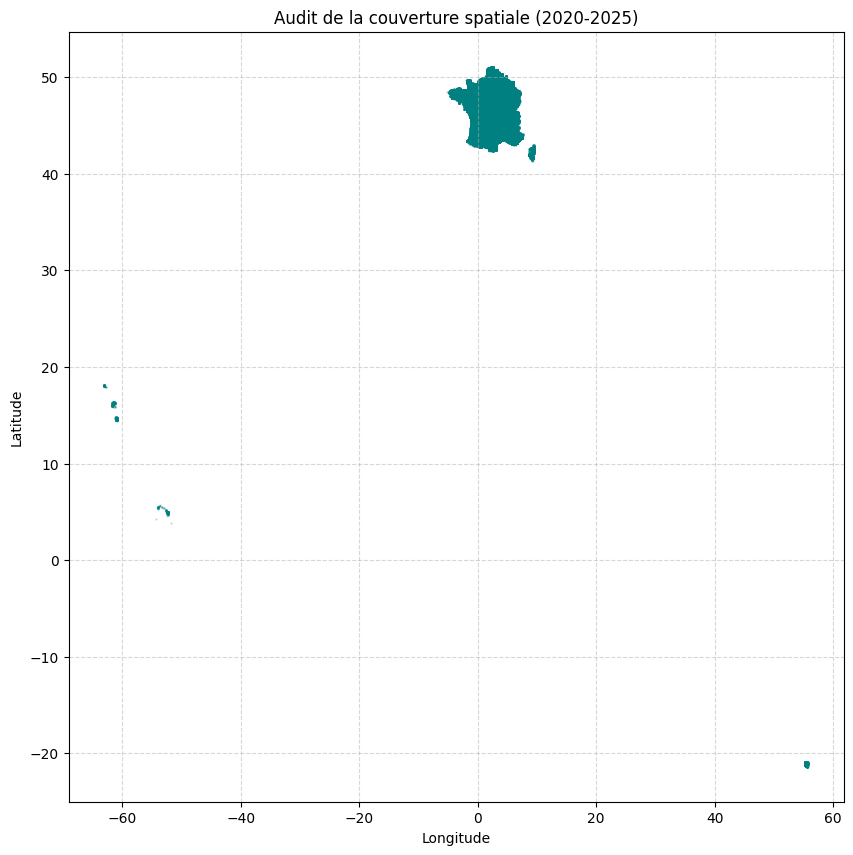

In [9]:
# Validation visuelle de la répartition géographique
plt.figure(figsize=(10, 10))
# On utilise un échantillon pour ne pas saturer la mémoire et l'affichage
df_geo_audit = df.sample(200000) 

plt.scatter(df_geo_audit['longitude'], df_geo_audit['latitude'], s=0.5, alpha=0.2, color='teal')

plt.title("Audit de la couverture spatiale (2020-2025)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 1ere Analyse de la Multicolinéarité (Corrélations) - comment les variables numériques interagissent entre elles.

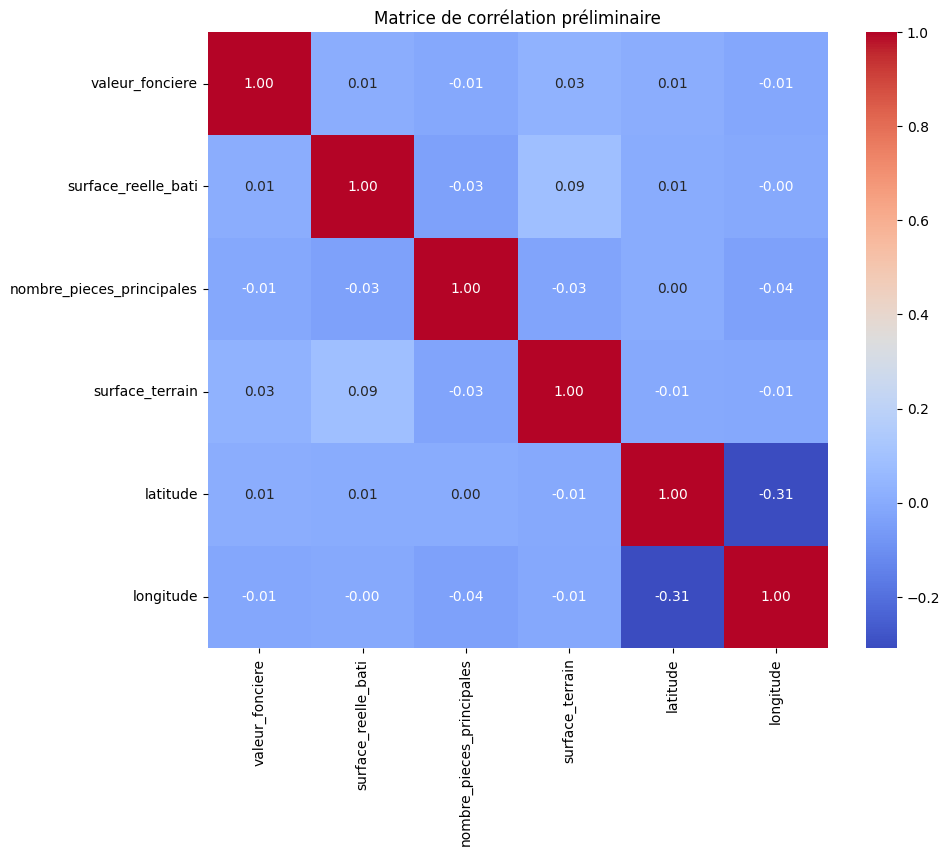

In [8]:
# Uniquement sur les colonnes numériques pertinentes
cols_etude = ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'latitude', 'longitude']
corr = df[cols_etude].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation préliminaire")
plt.show()

## Export fichier DVF 2020 à 2025

In [13]:
# Export en CSV compressé (Gzip)
df.to_csv('data_dvf_conso.csv.gz', index=False, compression='gzip')

print("✅ Export CSV compressé terminé avec succès.")

✅ Export CSV compressé terminé avec succès.
